# Análisis exploratorio

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import random_split, DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

SEED = 23183 
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando device: {device}")

Usando device: cpu


In [2]:
import ssl
import certifi
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

## Cargar el dataset

In [3]:
train_raw = MNIST(root="./data", train=True, download=True)
test_raw  = MNIST(root="./data", train=False, download=True)

### ¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Las clases están balanceadas?

In [4]:
print(f"Observaciones en train: {len(train_raw)}")
print(f"Observaciones en test:  {len(test_raw)}")
print(f"Total: {len(train_raw) + len(test_raw)}")

Observaciones en train: 60000
Observaciones en test:  10000
Total: 70000


In [5]:
classes = train_raw.classes
print("Clases:", classes)
print(f"Número de clases: {len(classes)}")

Clases: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Número de clases: 10


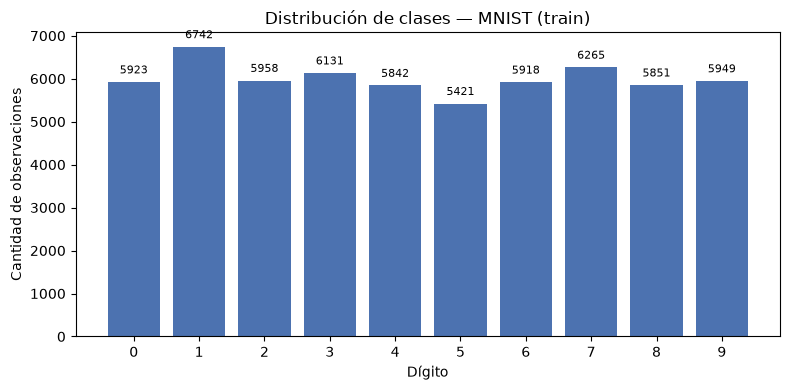

{np.int64(0): 5923, np.int64(1): 6742, np.int64(2): 5958, np.int64(3): 6131, np.int64(4): 5842, np.int64(5): 5421, np.int64(6): 5918, np.int64(7): 6265, np.int64(8): 5851, np.int64(9): 5949}

Mínimo: 5421, Máximo: 6742
Desviación relativa: 22.0%


In [6]:
labels = train_raw.targets.numpy()
counts = Counter(labels)
counts_sorted = dict(sorted(counts.items()))

plt.figure(figsize=(8, 4))
plt.bar(counts_sorted.keys(), counts_sorted.values(), color="#4C72B0")
plt.xlabel("Dígito")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de clases — MNIST (train)")
plt.xticks(range(10))
for digit, cnt in counts_sorted.items():
    plt.text(digit, cnt + 200, str(cnt), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print(counts_sorted)
print(f"\nMínimo: {min(counts_sorted.values())}, Máximo: {max(counts_sorted.values())}")
print(f"Desviación relativa: {(max(counts_sorted.values()) - min(counts_sorted.values())) / np.mean(list(counts_sorted.values())) * 100:.1f}%")

### ¿Cuál es la dimensión de cada imagen y qué rango de valores tienen los píxeles?

In [7]:
img, label = train_raw[0]
print(f"Tipo de objeto: {type(img)}")
print(f"Tamaño de la imagen (PIL): {img.size}")  # (ancho, alto)
print(f"Modo de color: {img.mode}")

img_array = np.array(img)
print(f"\nComo array de NumPy: shape = {img_array.shape}, dtype = {img_array.dtype}")
print(f"Valor mínimo de píxel: {img_array.min()}")
print(f"Valor máximo de píxel: {img_array.max()}")

Tipo de objeto: <class 'PIL.Image.Image'>
Tamaño de la imagen (PIL): (28, 28)
Modo de color: L

Como array de NumPy: shape = (28, 28), dtype = uint8
Valor mínimo de píxel: 0
Valor máximo de píxel: 255


### ¿Es necesario normalizar los valores de los píxeles?

Sí. Aunque MNIST no tiene outliers de escala como otros datasets, normalizar sigue siendo importante por varias razones prácticas para entrenar redes neuronales:

- **Estabilidad numérica y del gradiente:** con entradas en [0, 255], las activaciones y gradientes iniciales tienden a ser grandes, lo que puede provocar gradientes inestables o saturar funciones de activación como sigmoid/tanh.
- **Convergencia más rápida:** los optimizadores basados en gradiente (SGD, Adam) convergen más rápido y de forma más estable cuando las entradas están en una escala pequeña y centrada (p. ej. [0, 1] o estandarizada con media 0 y desviación 1).
- **Consistencia con la inicialización de pesos:** los esquemas de inicialización (Xavier, Kaiming) asumen implícitamente que las activaciones de entrada tienen una escala razonable.

La transformación estándar es `transforms.ToTensor()` (que ya escala a [0, 1] dividiendo por 255) seguida opcionalmente de `transforms.Normalize(mean, std)` con la media y desviación estándar del dataset (para MNIST, comúnmente `mean=0.1307`, `std=0.3081`, calculadas sobre el set de entrenamiento).

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = MNIST(root="./data", train=False, download=True, transform=transform)

img_t, label_t = train_dataset[0]
print(f"Shape del tensor: {img_t.shape}")  # [canales, alto, ancho]
print(f"Rango tras normalizar: [{img_t.min():.3f}, {img_t.max():.3f}]")

Shape del tensor: torch.Size([1, 28, 28])
Rango tras normalizar: [-0.424, 2.821]


### Visualice al menos 10 ejemplos del dataset con su etiqueta correspondiente.

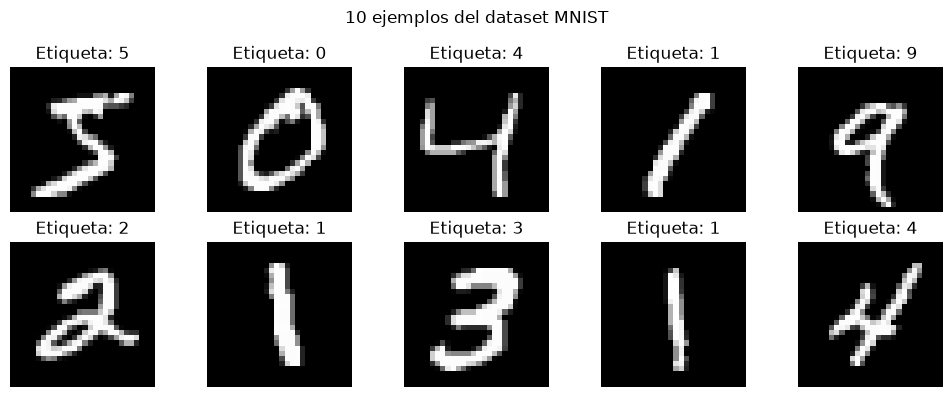

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_raw[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Etiqueta: {label}")
    ax.axis("off")
plt.suptitle("10 ejemplos del dataset MNIST")
plt.tight_layout()
plt.show()

## División en entrenamiento y prueba

In [10]:
val_fraction = 0.15
n_val = int(len(train_dataset) * val_fraction)
n_train = len(train_dataset) - n_val

generator = torch.Generator().manual_seed(SEED)
train_split, val_split = random_split(train_dataset, [n_train, n_val], generator=generator)

print(f"Entrenamiento: {len(train_split)} observaciones")
print(f"Validación:    {len(val_split)} observaciones")
print(f"Test:          {len(test_dataset)} observaciones")

BATCH_SIZE = 64
train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_split, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Entrenamiento: 51000 observaciones
Validación:    9000 observaciones
Test:          10000 observaciones


# Investigación

nn.Conv2d
Aplica convolución 2D, desliza un conjunto de filtros aprendibles sobre la imagen para extraer características locales. Cada filtro produce un mapa de características. Los parámetros principales son: 
in_channels: canales de entrada
out_channels: número de filtros = canales de salida
kernel_size: tamaño del filtro 
stride: paso del deslizamiento 
padding: relleno de ceros en los bordes, para controlar el tamaño de salida

nn.MaxPool2d
Reduce la resolución espacial tomando el valor máximo dentro de cada ventana. Aporta invarianza a pequeñas traslaciones y reduce el costo computacional de capas siguientes. Los parámetros principales son:
kernel_size: tamaño de la ventana 
stride: usualmente es igual a kernel_size, para no solapar

nn.AvgPool2d
Igual que MaxPool pero toma el promedio en vez del máximo. Suaviza más la información, es menos agresivo que Max, útil cuando se quiere preservar información de contexto en vez de solo la activación más fuerte. Los parámetros principales son: kernel_size y stride

nn.BatchNorm2d
Normaliza las activaciones de cada canal a media 0 / varianza 1 dentro de cada mini-batch, y luego aplica una escala y desplazamiento aprendibles. Acelera y estabiliza el entrenamiento, permite tasas de aprendizaje más altas y actúa como regularizador. Los parámetros principales son:
num_features: número de canales de entrada, debe coincidir con out_channels de la capa Conv2d
eps
momentum: para las estadísticas móviles usadas en inferencia

nn.Flatten
Aplana un tensor multidimensional a un vector por observación, es necesario para pasar de las capas convolucionales a capas totalmente conectadas. Los parámetros principales son: 
start_dim: dimensión desde la cual aplanar, por defecto 1.

nn.CrossEntropyLos
Función de pérdida estándar para clasificación multiclase. Combina internamente LogSoftmax + NLLLoss: espera logits crudos como entrada y las etiquetas como enteros de clase. Los parámetros principales son: 
Weight: para ponderar clases desbalanceadas
Reduction: 'mean', 'sum' o 'none'

Tensor
Es la estructura de datos fundamental de PyTorch: un arreglo multidimensional de números, con dos capacidades extra que lo hacen apto para deep learning:
1. Cómputo en GPU: un tensor puede vivir en memoria de GPU y todas las operaciones se ejecutan aceleradas por hardware.
2. Autograd: PyTorch puede construir automáticamente un grafo computacional sobre las operaciones hechas con tensores  y calcular gradientes vía backpropagation.
En el contexto de una CNN, las imágenes se representan como tensores de 4 dimensiones.

Campo receptivo
El campo receptivo de una neurona en una capa convolucional es la región de la imagen de entrada original que influye en el valor de esa neurona. En la primera capa convolucional, el campo receptivo es simplemente el tamaño del kernel. A medida que se apilan más capas convolucionales y especialmente capas de pooling, que lo agrandan más rápido, el campo receptivo efectivo de las neuronas en capas profundas crece, permitiendo que vean regiones cada vez más grandes de la imagen y capturen patrones más globales y complejos.
Las primeras capas aprenden características locales genéricas, y conforme el campo receptivo crece, las capas más profundas combinan esa información local en representaciones cada vez más  globales.

¿Por qué las CNN requieren menos parámetros que un MLP equivalente?
1. Compartición de pesos: en un MLP, cada neurona de la primera capa oculta tiene una conexión distinta con cada píxel de la imagen. En una CNN, un filtro convolucional de 3×3 tiene 9 pesos (+1 bias), y ese mismo se reutiliza sobre toda la imagen. El número de parámetros de una capa depende del tamaño del kernel y del número de filtros, no del tamaño de la imagen de entrada.
2. Conectividad local: en un MLP cada neurona ve la imagen completa. En una CNN, cada neurona de una capa convolucional solo ve una ventana local de la capa anterior, no la imagen entera. Esto reduce el número de conexiones.
Como consecuencia, una CNN con varias capas convolucionales puede tener muchos menos parámetros que un MLP, y además esos parámetros están mejor especializados para la estructura espacial de las imágenes, lo que lleva a una mejor generalización con menos datos y menos riesgo de overfitting.